In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import BernoulliNB, GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from imblearn.under_sampling import RandomUnderSampler

df = pd.read_csv('Dataset/bank-full.csv',sep=';')

df_binaria = df[['default','housing','loan','y']]
df_numerica = df[['age','balance','duration','campaign','pdays','previous','y']]

---------------------------------------------------------------------------------------------------------------------------------------------

Bernoulli-Naive-Bayes

In [3]:
map_bin = {'yes':1,'no':0}
df_binaria = df_binaria.replace(map_bin)

display(df_binaria.sample(5))

C:\Users\User\AppData\Local\Temp\ipykernel_14932\3819871324.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_binaria = df_binaria.replace(map_bin)


,default,housing,loan,y
41186,0,0,0,1
28691,0,0,0,0
7735,0,1,0,0
43021,0,0,0,1
1919,0,0,1,0


A acurácia do modelo Bernoulli-Naive-Bayes foi de 64.14%


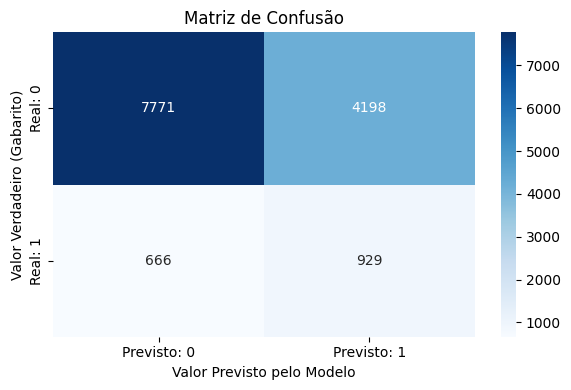

In [4]:
Y = df_binaria['y']
X = df_binaria.drop(columns=['y'])

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=0)

rus = RandomUnderSampler(random_state=0)
X_train_balanceado, y_train_balanceado = rus.fit_resample(X_train, y_train)
#display(y_train_balanceado.value_counts())

modelo = BernoulliNB()

modelo.fit(X_train_balanceado,y_train_balanceado)

Y_predict = modelo.predict(X_test)

accuracy = accuracy_score(y_test,Y_predict)
print(f'A acurácia do modelo Bernoulli-Naive-Bayes foi de {accuracy*100:.2f}%')

matriz_c = confusion_matrix(y_test,Y_predict)
#print(matriz_c)

plt.figure(figsize=(6, 4))
# annot=True mostra os números, fmt='d' garante que sejam inteiros
sns.heatmap(matriz_c, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto: 0', 'Previsto: 1'], 
            yticklabels=['Real: 0', 'Real: 1'])

plt.title('Matriz de Confusão')
plt.ylabel('Valor Verdadeiro (Gabarito)')
plt.xlabel('Valor Previsto pelo Modelo')
plt.tight_layout()
plt.show()

CONCLUSÃO: Isto é, o fato de que a pessoa está devendo ou não, ou se ela tem ou não algum empréstimo não carrega muita informação sobre o fato de que ela vai ou não contratar o serviço OU o fato de haver muito mais pessoas que não tem empréstimo ou estão inadimplente, afeta bastante o algoritmo de Naive-Bayes e não permite que o mesmo reconheça padrões (Acredito que seja a segunda opção).

SOLUÇÃO: Aplicar um modelo mais sofisticado.

---------------------------------------------------------------------------------------------------------------------------------------------

Gaussian-Naive-Bayes

In [5]:
display(df_numerica.sample(5))
display(df_numerica.describe())

,age,balance,duration,campaign,pdays,previous,y
5796,55,-473,233,1,-1,0,no
43746,70,4531,445,1,-1,0,no
43226,39,53,257,1,394,1,yes
35934,55,481,147,2,298,3,no
37746,43,214,335,1,-1,0,no


,age,balance,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,4918.000000,63.000000,871.000000,275.000000


In [6]:
df_numerica = df_numerica.drop(columns=['pdays','campaign','previous'])

In [7]:
mapeamento = {'yes':1,'no':0}
df_numerica = df_numerica.replace(mapeamento)

display(df_numerica.sample(5))
display(df_numerica.describe())

display(df_numerica['y'].value_counts())

C:\Users\User\AppData\Local\Temp\ipykernel_14932\1328564405.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numerica = df_numerica.replace(mapeamento)


,age,balance,duration,y
6376,28,891,377,0
25560,36,-485,278,0
37,53,-3,1666,0
43162,34,173,36,0
42942,28,266,108,0


,age,balance,duration,y
count,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,258.163080,0.116985
std,10.618762,3044.765829,257.527812,0.321406
min,18.000000,-8019.000000,0.000000,0.000000
25%,33.000000,72.000000,103.000000,0.000000
50%,39.000000,448.000000,180.000000,0.000000
75%,48.000000,1428.000000,319.000000,0.000000
max,95.000000,102127.000000,4918.000000,1.000000


y
0    39922
1     5289
Name: count, dtype: int64

A acurácia do modelo Gaussian-Naive-Bayes foi de 84.07%


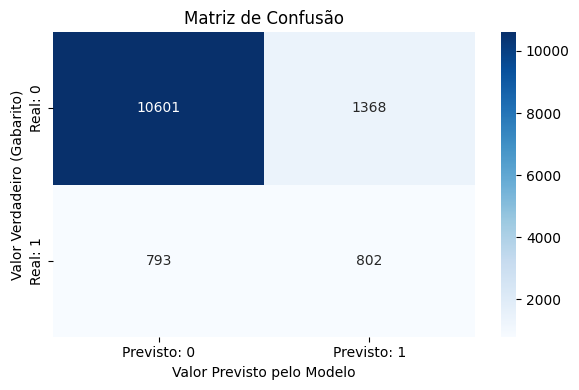

In [8]:
Y = df_numerica['y']
X = df_numerica.drop(columns=['y'])

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=0)

rus = RandomUnderSampler(random_state=0)
X_train_balanceado, y_train_balanceado = rus.fit_resample(X_train, y_train)

modelo = GaussianNB()

modelo.fit(X_train_balanceado,y_train_balanceado)

Y_predict = modelo.predict(X_test)

accuracy = accuracy_score(y_test,Y_predict)
print(f'A acurácia do modelo Gaussian-Naive-Bayes foi de {accuracy*100:.2f}%')

matriz_c = confusion_matrix(y_test,Y_predict)
#print(matriz_c)

plt.figure(figsize=(6, 4))
# annot=True mostra os números, fmt='d' garante que sejam inteiros
sns.heatmap(matriz_c, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto: 0', 'Previsto: 1'], 
            yticklabels=['Real: 0', 'Real: 1'])

plt.title('Matriz de Confusão')
plt.ylabel('Valor Verdadeiro (Gabarito)')
plt.xlabel('Valor Previsto pelo Modelo')
plt.tight_layout()
plt.show()

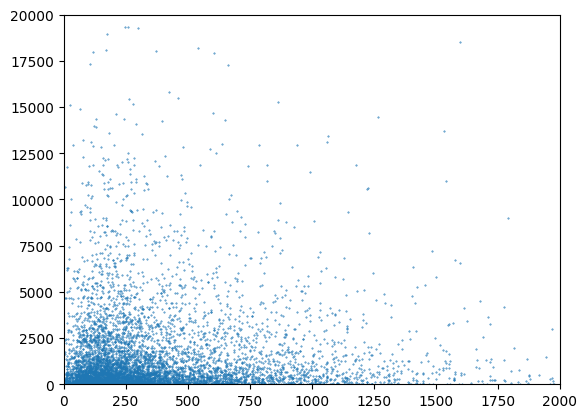

In [13]:
X_plot = np.array(X_train_balanceado)

plt.figure()

plt.plot(X_plot[:,2],X_plot[:,1],'o',markersize='0.4')

plt.xlim(0,2000)
plt.ylim(0,20000)

plt.show()